# 3. Dependence models

All methods retain the same frozen marginal quantile grid. They differ only in the Gaussian-copula correlation matrix $R_{g,\tau}^{(i)} \in \mathbb R^{K_g\times K_g}$ that couples entity-wise uniforms before projection onto those fixed quantiles. This notebook calls `train_from_config`, the function behind the training CLI, so all splits, full-group assertions, checkpoints, and metadata are identical.

M0 uses $R=I$. M1 estimates a static lead-specific correlation from training pseudo-scores. M2 maps each entity's frozen-marginal features to low-rank factor parameters, $\Sigma=\Lambda\Lambda^T+\operatorname{diag}(\sigma^2)$, then normalizes to a correlation. M3 first uses entity self-attention over the complete static group, then applies the same low-rank construction. M4 is an optional bounded kernel diagnostic, not a core method.

In [1]:
import os
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = Path.cwd() / 'notebooks' if (Path.cwd() / 'notebooks').is_dir() else Path.cwd()
sys.path.insert(0, str(NOTEBOOK_DIR))
from _helpers import REPOSITORY_ROOT, cache_path, resolve_config
os.chdir(REPOSITORY_ROOT)
from simcast.cli.train_dependence import train_from_config
from simcast.fm.cache import load_pit_library

CONFIG_FILE = 'configs/liander2024_transformer.yaml'
OVERRIDES: tuple[str, ...] = ()
METHOD = 'static_gaussian'  # independent, static_gaussian, conditional_low_rank, set_aware_low_rank, conditional_kernel
TRAIN_MODEL = False
OUTPUT_DIR = Path('runs/notebook_transformer_m1')  # Must not already exist if training is enabled.
config = resolve_config(CONFIG_FILE, OVERRIDES)
config = config.model_copy(update={'dependence': config.dependence.model_copy(update={'method': METHOD})})
CACHE_DIR = cache_path(config)
print('method:', config.dependence.method)
print('cache:', CACHE_DIR)
assert config.protocol.full_group_only and not config.subset_training.enabled

method: static_gaussian
cache: /home/kbolat/Python/simcast/artifacts/cache/liander2024_transformer


## Training data visible to the dependence model

Only the training split is used to fit M0--M3. Validation pseudo-scores guide early stopping for conditional models but do not refit the feature standardizer. Test labels remain unavailable in this cell. The `pit_z` tensor is arranged as `[origin, entity, lead]`; all $K_g$ entity scores in a valid vector are finite or all are invalid.

In [2]:
library = load_pit_library(CACHE_DIR, access='training')
ds = library.dataset
train_mask = ds['split'].values == 'train'
train_z = ds['pit_z'].values[train_mask]
complete = np.isfinite(train_z).all(axis=1)
print('train z shape [origin, entity, lead]:', train_z.shape)
print('complete training vectors:', complete.sum(), '/', complete.size)
assert train_z.shape[1] == len(ds['entity_id'])
assert np.isnan(ds['true_y'].where(ds['split'] == 'test')).all()

train z shape [origin, entity, lead]: (222, 15, 96)
complete training vectors: 18088 / 21312


## Fit exactly as the CLI does

Set `TRAIN_MODEL=True` only after choosing a new output directory. The resulting `run_metadata.json`, resolved configuration, checkpoint, and training plot are exactly the artifacts created by `uv run python -m simcast.cli.train_dependence`. No notebook-specific training loop exists.

For M2/M3, the trainer asserts the entity dimension equals the complete group's $K_g$ at every batch. M3 is permutation equivariant: permuting input entities permutes its correlation as $P R P^T$, with no entity-ID embedding used.

In [3]:
if TRAIN_MODEL:
    run_dir = train_from_config(config, cache_dir=CACHE_DIR, output_dir=OUTPUT_DIR)
    print(run_dir)
else:
    print('Training disabled. Set TRAIN_MODEL=True to create a new method run.')

Training disabled. Set TRAIN_MODEL=True to create a new method run.


## Inspect a fitted static correlation

For M1 only, a saved model has a direct static lead-specific matrix. This visualization is descriptive: it shows the learned dependence among the complete ordered entity list. It does not alter the model or select entities. M2/M3 correlations depend on a particular forecast instance and lead and are written during evaluation through their standard checkpoints.

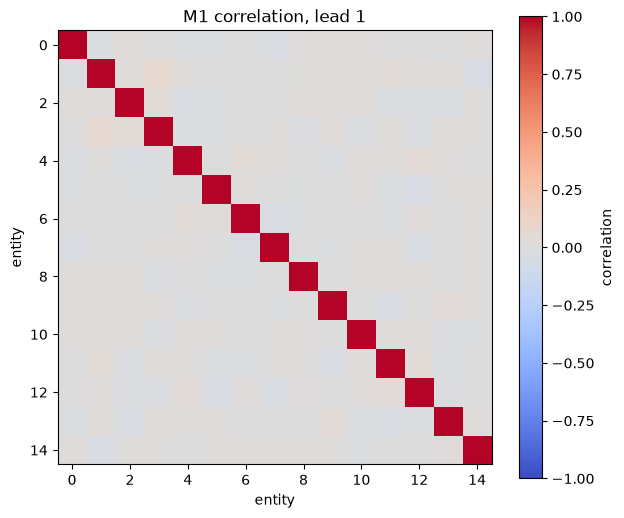

In [ ]:
from simcast.dependence.static_gaussian import StaticGaussianCopula

STATIC_MODEL_PATH: Path | None = None  # Example: Path('runs/notebook_transformer_m1/model.npz')
if STATIC_MODEL_PATH is not None:
    m1 = StaticGaussianCopula.load(STATIC_MODEL_PATH)
    lead = 1
    matrix = m1.correlation_matrix(lead=lead).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix, vmin=-1, vmax=1, cmap='coolwarm')
    ax.set(title=f'M1 correlation, lead {lead}', xlabel='entity', ylabel='entity')
    fig.colorbar(image, ax=ax, label='correlation')
    assert matrix.shape == (len(ds['entity_id']), len(ds['entity_id']))
else:
    print('Set STATIC_MODEL_PATH after fitting or selecting an M1 run.')